<h2 align="center">SMS Spam Classification Using Naive Bayes</h2>

### Import libaries 

In [10]:
import pandas as pd 
from sklearn.model_selection import train_test_split

### Load Csv file 

In [4]:
df = pd.read_csv("spam.csv")
df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [5]:
df.shape

(5572, 2)

In [6]:
df.Category.unique()

array(['ham', 'spam'], dtype=object)

In [9]:
df.Category.value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

### Train test split 

In [42]:
X_train , X_test , Y_train , Y_test = train_test_split(df.Message , df.Category , test_size=0.3 , random_state=42)
X_train.shape
X_test.shape

(1672,)

### Feature Engineering: Convert Text into Vector

In [28]:
from sklearn.feature_extraction.text import CountVectorizer
v= CountVectorizer()
X_train_transform = v.fit_transform(X_train.values)
X_test_transform = v.transform(X_test.values)

X_train_transform.toarray()[:2]



array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2, 7262))

### Train the model using Navie Bayes classification 

In [32]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_transform , Y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Model Evaluation: Precision, Recall and F1-Score

In [45]:
y_predict = model.predict(X_test_transform)
from sklearn.metrics import classification_report
report = classification_report(Y_test , y_predict)
print(report)


              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1448
        spam       0.98      0.95      0.96       224

    accuracy                           0.99      1672
   macro avg       0.99      0.97      0.98      1672
weighted avg       0.99      0.99      0.99      1672



### Plot the confusion matrix 

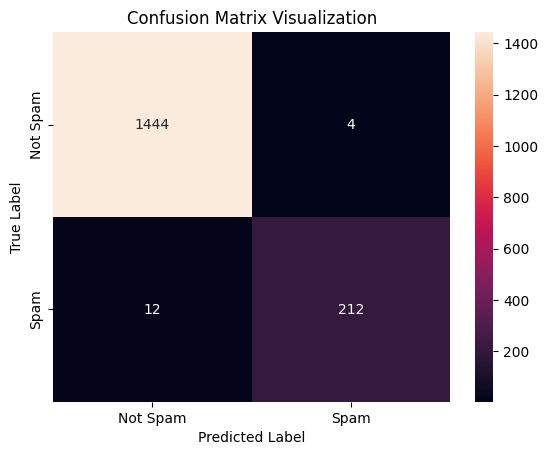

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib import pyplot as plt

cm = confusion_matrix(Y_test , y_predict)
sns.heatmap(cm , annot=True , fmt="d", xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'] )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualization')
plt.show()


### Its time to prediction on sample email 

In [57]:
emails = [
        'Hey mohan, can we get together to watch footbal game tomorrow?',
         'parking, exclusive offer just for you. Dont miss this reward!' , 
        'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
    ]
emails_count = v.transform(emails)
model.predict(emails_count)

array(['ham', 'ham', 'spam'], dtype='<U4')

### Now do same thing using Sklearn Pipeline with Few Lines of Code

In [67]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([
          ( "Vectorizer" , CountVectorizer()) ,
          ( "nb" , MultinomialNB()) 
   ])
pipe.fit(X_train , Y_train)
y_pred = pipe.predict(X_test)
report = classification_report(Y_test , y_pred)
print(report)

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1448
        spam       0.98      0.95      0.96       224

    accuracy                           0.99      1672
   macro avg       0.99      0.97      0.98      1672
weighted avg       0.99      0.99      0.99      1672



In [ ]:
 We are doing both of approch with pipeline and without pipeline . Pipeline is very useful insted of using without pipeline it is beacause Pipeline helps to reduce a code . 